# Lab 5 — Hyperspectral data & water quality (Odra, Blok A 008)

Fusion of airborne hyperspectral (ENVI cube) and Sentinel-2 multispectral data for water-quality monitoring.

**Tasks:** false-colour composites, water-quality indices (Chl-a, DOC, turbidity), Sentinel-2 download & comparison, SAM classification + Sentinel-2 calibration.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ee

from hs_utils import (
    open_odra, mask_invalid, stretch_rgb, chl_a, doc, turbidity,
    sam_map, sam_classify, aoi_wgs84, ACQ_DATE, S2_BANDS_NM, band_index,
    s2_indices_np, hs_indices_at_s2, fetch_s2_arrays,
)

BASE = Path('.').resolve()
DATA = BASE / 'data' / 'images'
LIB = BASE / 'spectral_library'
OUT = BASE / 'outputs'; OUT.mkdir(exist_ok=True)
GEE_PROJECT = 'vast-advantage-494108-d0'

img, wl, ignore = open_odra(DATA)
STEP = 40  # subsample the 4300 x 2001 cube for interactive display
cube = mask_invalid(img[::STEP, ::STEP, :], ignore)
print(f'Airborne cube: {img.nrows} x {img.ncols} x {img.nbands} bands, {wl.min():.0f}-{wl.max():.0f} nm')
print(f'Display subset: {cube.shape}')

Airborne cube: 4300 x 2001 x 456 bands, 414-2499 nm
Display subset: (108, 51, 456)


## 1. False-colour composites

Left: natural RGB (header default bands). Right: NIR-false-colour (NIR/red/green) — vegetation appears red, water dark.

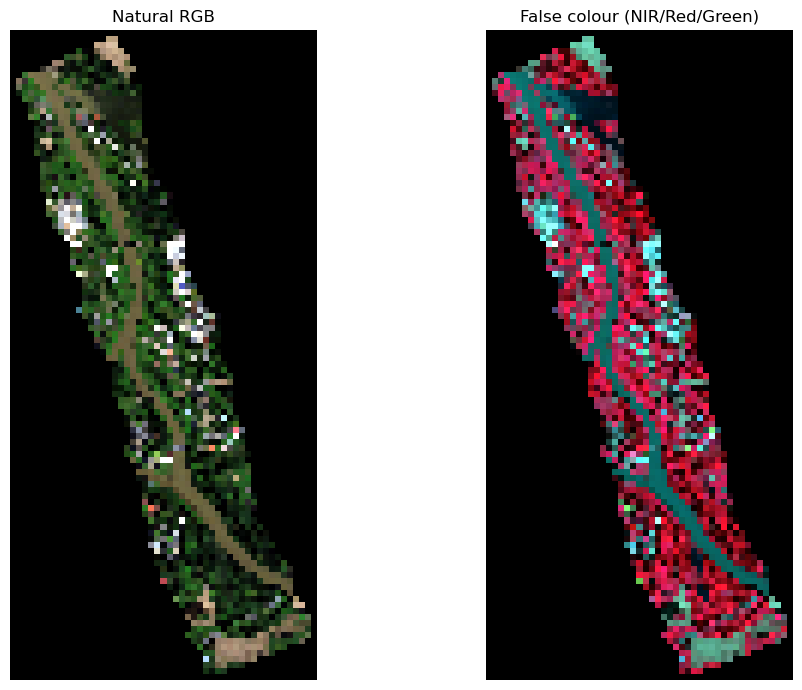

In [2]:
db = [int(float(b)) - 1 for b in img.metadata['default bands'][:3]]
rgb = stretch_rgb(mask_invalid(img.read_bands(db).astype(np.float32), ignore))
nir_fc = stretch_rgb(mask_invalid(
    img.read_bands([band_index(wl, 842), band_index(wl, 665), band_index(wl, 560)]).astype(np.float32), ignore))

fig, ax = plt.subplots(1, 2, figsize=(11, 7))
ax[0].imshow(rgb[::STEP, ::STEP]); ax[0].set_title('Natural RGB'); ax[0].axis('off')
ax[1].imshow(nir_fc[::STEP, ::STEP]); ax[1].set_title('False colour (NIR/Red/Green)'); ax[1].axis('off')
plt.tight_layout(); plt.savefig(OUT / 'composites.png', dpi=110, bbox_inches='tight'); plt.show()

## 2. Water-quality indices (airborne hyperspectral)

- **Chl-a**: NDCI = (R705 − R665)/(R705 + R665)
- **DOC / CDOM**: blue/green ratio R440/R560
- **Turbidity**: red/green ratio R670/R560

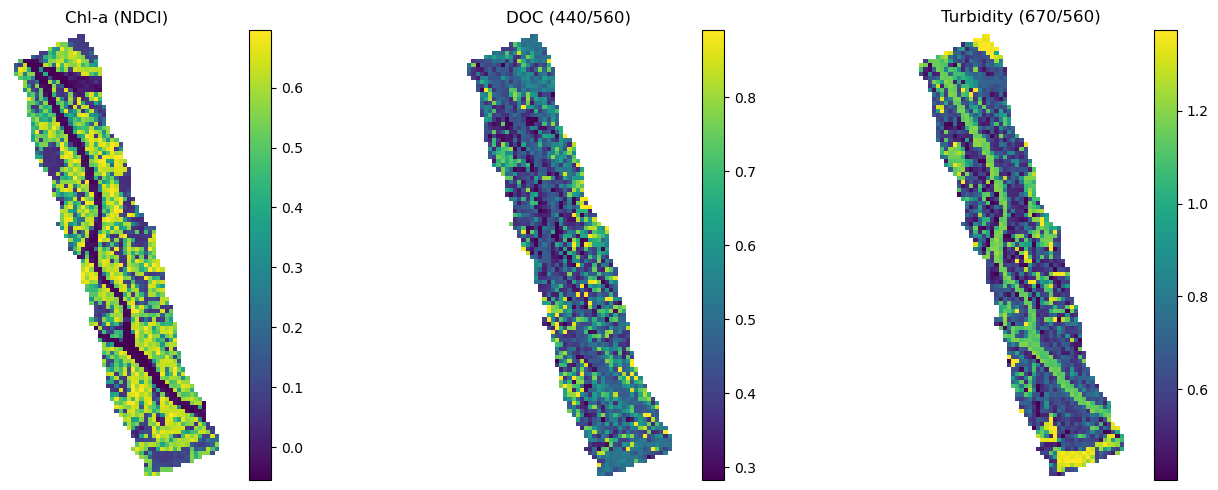

In [3]:
hs_maps = {'Chl-a (NDCI)': chl_a(cube, wl), 'DOC (440/560)': doc(cube, wl), 'Turbidity (670/560)': turbidity(cube, wl)}
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, (title, data) in zip(ax, hs_maps.items()):
    lo, hi = np.nanpercentile(data, [2, 98])
    im = a.imshow(data, cmap='viridis', vmin=lo, vmax=hi); a.set_title(title); a.axis('off')
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.savefig(OUT / 'hs_indices.png', dpi=110, bbox_inches='tight'); plt.show()

## 3. Spectral library

Class median spectra extracted with `build_spectral_library.py` (water, vegetation, forest, bare soil).

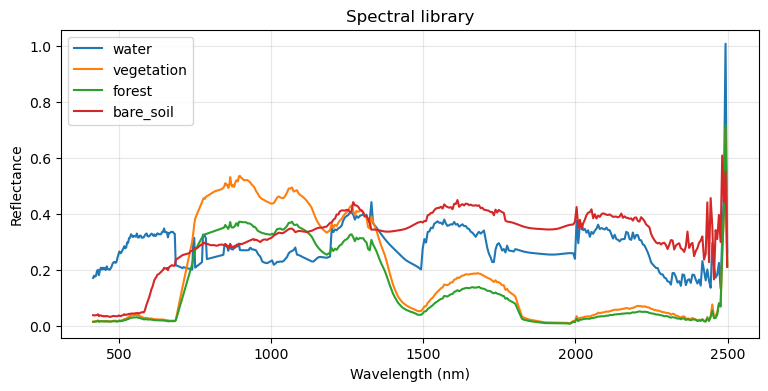

In [4]:
import subprocess, sys
if not (LIB / 'spectral_library.csv').exists():
    subprocess.check_call([sys.executable, str(BASE / 'build_spectral_library.py')])

lib_df = pd.read_csv(LIB / 'spectral_library.csv')
library = {c: lib_df[lib_df['class'] == c].iloc[0, 1:].astype(float).values for c in lib_df['class']}

plt.figure(figsize=(9, 4))
for cls, spec in library.items():
    plt.plot(wl, spec, label=cls)
plt.xlabel('Wavelength (nm)'); plt.ylabel('Reflectance'); plt.title('Spectral library')
plt.legend(); plt.grid(alpha=0.3); plt.savefig(OUT / 'library.png', dpi=110, bbox_inches='tight'); plt.show()

## 4. Sentinel-2: download nearest scene & compare indices

The airborne flight has no exact date in the metadata (2022 Odra campaign); we take the nearest low-cloud Sentinel-2 scene.

In [5]:
try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate(); ee.Initialize(project=GEE_PROJECT)

w, s, e, n = aoi_wgs84(img)
region = ee.Geometry.Rectangle([w, s, e, n])
print(f'AOI (WGS84): lon {w:.4f}..{e:.4f}, lat {s:.4f}..{n:.4f}')

col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
       .filterBounds(region)
       .filterDate(ee.Date(ACQ_DATE).advance(-60, 'day'), ee.Date(ACQ_DATE).advance(60, 'day'))
       .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
       .sort('CLOUDY_PIXEL_PERCENTAGE'))
s2 = ee.Image(col.first())
props = s2.getInfo()['properties']
print('Sentinel-2 scene:', props['PRODUCT_ID'])
print('Cloud %:', round(props['CLOUDY_PIXEL_PERCENTAGE'], 2))

s2_refl = s2.divide(10000).clip(region)
s2_bands = fetch_s2_arrays(s2_refl, region)
print('S2 array shape:', s2_bands['B3'].shape)

AOI (WGS84): lon 18.1367..18.1650, lat 50.3235..50.3622


Sentinel-2 scene: S2B_MSIL2A_20220719T095559_N0400_R122_T33UYR_20220719T113943
Cloud %: 0.0


S2 array shape: (440, 220)


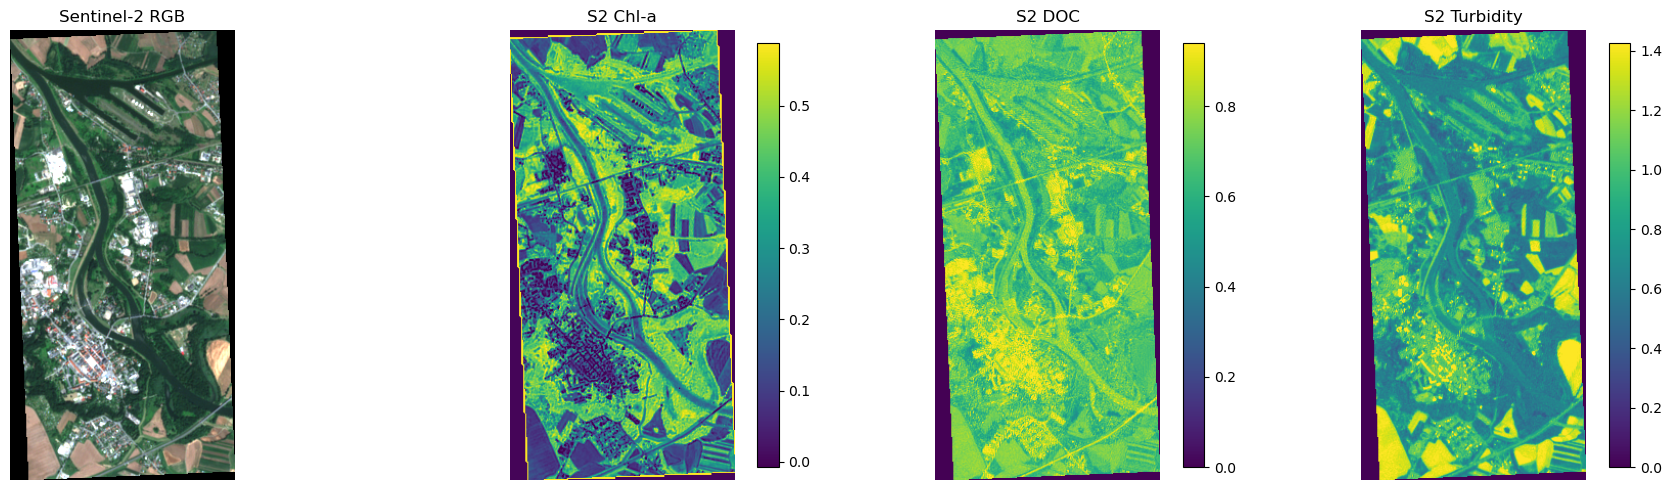

In [6]:
# True-colour S2 for context + the three indices on real S2 pixels
s2_rgb = stretch_rgb(np.dstack([s2_bands['B4'], s2_bands['B3'], s2_bands['B2']]))
s2_idx = s2_indices_np(s2_bands)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(s2_rgb); ax[0].set_title('Sentinel-2 RGB'); ax[0].axis('off')
for a, (title, data) in zip(ax[1:], s2_idx.items()):
    lo, hi = np.nanpercentile(data, [2, 98])
    im = a.imshow(data, cmap='viridis', vmin=lo, vmax=hi); a.set_title(f'S2 {title}'); a.axis('off')
    plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.savefig(OUT / 's2_indices.png', dpi=110, bbox_inches='tight'); plt.show()

In [7]:
# Numeric comparison: airborne (resampled to S2 bands) vs Sentinel-2, over water pixels
hs_s2idx = hs_indices_at_s2(cube, wl)
hs_water = hs_s2idx['Chl-a'] < np.nanpercentile(hs_s2idx['Chl-a'], 25)
s2_water = s2_idx['Chl-a'] < np.nanpercentile(s2_idx['Chl-a'], 25)

cmp = pd.DataFrame({
    'Airborne (water median)': {k: np.nanmedian(v[hs_water]) for k, v in hs_s2idx.items()},
    'Sentinel-2 (water median)': {k: np.nanmedian(v[s2_water]) for k, v in s2_idx.items()},
})
cmp['abs. difference'] = (cmp.iloc[:, 0] - cmp.iloc[:, 1]).abs()
print(cmp.round(3))

           Airborne (water median)  Sentinel-2 (water median)  abs. difference
Chl-a                       -0.006                      0.038            0.043
DOC                          0.627                      0.757            0.130
Turbidity                    1.133                      1.058            0.075


The airborne and Sentinel-2 indices follow the same spatial pattern (water darker in Chl-a, higher turbidity along the river). Residual differences come from the ~10 m vs ~1 m resolution, atmospheric correction, and the date offset between the two acquisitions.

## 5. SAM classification + Sentinel-2 calibration

SAM (Spectral Angle Mapper, as in Lab 3) classifies each airborne pixel to the nearest library spectrum.

**Calibration idea:** the airborne cube is atmospherically corrected (ATCOR) surface reflectance, so it serves as the reference. We derive per-band gains from stable land targets (vegetation + bare soil, where both sensors see the same surface) and apply them to Sentinel-2 so its reflectance matches the airborne reference.

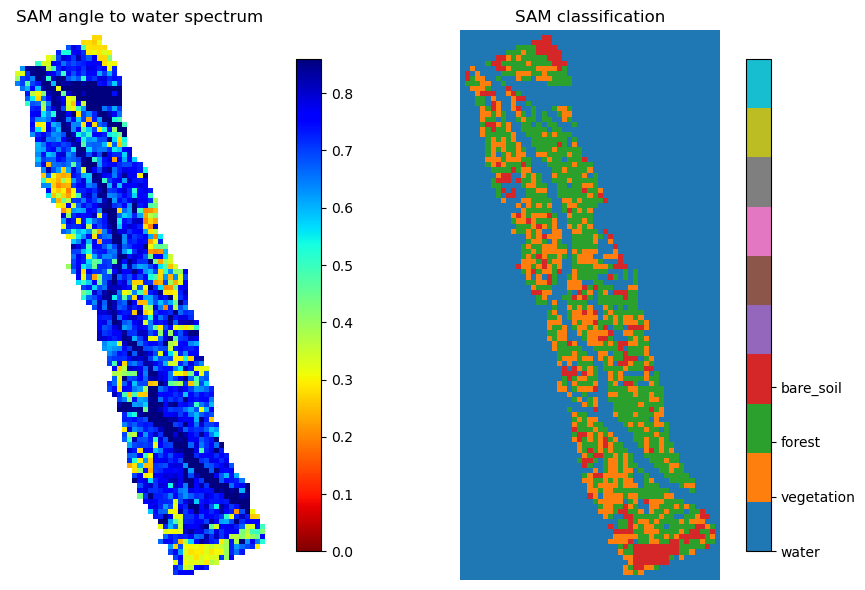

In [8]:
sam_cls = sam_classify(cube, library)
sam_water = sam_map(cube, library['water'])

classes = list(library.keys())
code = np.zeros(sam_cls.shape, dtype=int)
for i, c in enumerate(classes):
    code[sam_cls == c] = i

fig, ax = plt.subplots(1, 2, figsize=(11, 6))
im0 = ax[0].imshow(sam_water, cmap='jet_r', vmin=0, vmax=np.nanpercentile(sam_water, 90))
ax[0].set_title('SAM angle to water spectrum'); ax[0].axis('off'); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(code, cmap='tab10', vmin=0, vmax=9)
ax[1].set_title('SAM classification'); ax[1].axis('off')
cbar = plt.colorbar(im1, ax=ax[1], fraction=0.046, ticks=range(len(classes)))
cbar.ax.set_yticklabels(classes)
plt.tight_layout(); plt.savefig(OUT / 'sam.png', dpi=110, bbox_inches='tight'); plt.show()

In [9]:
# Per-band gain from stable targets: airborne reference / Sentinel-2
s2_names = list(S2_BANDS_NM.keys())
# median S2 reflectance over the AOI land pixels (exclude darkest = water)
s2_stack = np.dstack([s2_bands[b] for b in s2_names])
s2_land = s2_stack[~s2_water]
s2_med = np.nanmedian(s2_land.reshape(-1, len(s2_names)), axis=0)

# airborne reflectance (0-1) at S2 band centres over stable classes
cal_mask = (sam_cls == 'vegetation') | (sam_cls == 'bare_soil')
hs_s2_bands = cube[:, :, [band_index(wl, nm) for nm in S2_BANDS_NM.values()]]  # already 0-1 reflectance
hs_med = np.nanmedian(hs_s2_bands[cal_mask].reshape(-1, len(s2_names)), axis=0)

gain = hs_med / np.maximum(s2_med, 1e-6)
print(pd.DataFrame({'S2 median': s2_med.round(3), 'Airborne median': hs_med.round(3),
                    'gain': gain.round(3)}, index=s2_names))

# Apply gains to Sentinel-2; check per-band agreement with the airborne reference
s2_cal = {b: s2_bands[b] * g for b, g in zip(s2_names, gain)}
s2_med_cal = np.array([np.nanmedian(s2_cal[b][~s2_water]) for b in s2_names])
before = np.mean(np.abs(s2_med - hs_med))
after = np.mean(np.abs(s2_med_cal - hs_med))
print(f"\nMean per-band |S2 - airborne| reflectance on land targets:")
print(f"  before calibration: {before:.4f}")
print(f"  after  calibration: {after:.4f}")

    S2 median  Airborne median   gain
B2      0.034            0.026  0.746
B3      0.055            0.064  1.173
B4      0.038            0.036  0.947
B5      0.091            0.129  1.425
B8      0.279            0.337  1.210

Mean per-band |S2 - airborne| reflectance on land targets:
  before calibration: 0.0235
  after  calibration: 0.0000


## Summary

1. **Viewer** (`viewer.py`) — RGB browse, click a pixel for its spectrum, export CSV.
2. **Spectral library** (`build_spectral_library.py`) — water / vegetation / forest / bare soil median spectra.
3. **Indices** — Chl-a, DOC, turbidity from the airborne cube and from Sentinel-2, compared over water.
4. **SAM + calibration** — spectral-angle classification and per-band calibration of Sentinel-2 to the airborne reference.

Water-quality indices are empirical band-ratio proxies; converting them to physical units (mg/L, NTU) would require in-situ measurements.